# Actividad 4.1 — Modelado no supervisado con Covertype

**Pregunta de análisis:**  
¿Qué estructuras de agrupación pueden identificarse a partir de las características cartográficas y qué tan confiables y útiles resultan los grupos obtenidos?

**Unidad de análisis:** una celda territorial de 30 × 30 metros.

**Objetivo del notebook:** preparar los datos, reducir dimensionalidad con PCA incremental, construir y comparar modelos MiniBatch K-Means, evaluar estabilidad y calidad, validar externamente con `Cover_Type` **solo después de seleccionar el modelo**, y caracterizar los grupos.

> **Diseño para Google Colab:** se evita crear copias grandes innecesarias, se usa `float32`, PCA incremental, MiniBatch K-Means y muestras reproducibles para las métricas más costosas.

## 1. Librerías y configuración

Este notebook usa `fetch_covtype` de **scikit-learn**, por lo que no es necesario instalar `ucimlrepo`.

La primera ejecución descargará el conjunto de datos y después quedará en caché durante la sesión.

In [37]:
import os
import gc
import time
import warnings
import itertools
import importlib.metadata as md_pkg

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("figures", exist_ok=True)

print("Configuración lista.")

Configuración lista.


## 2. Carga de datos y separación inmediata de `Cover_Type`

`Cover_Type` se separa antes de cualquier transformación y **no se utiliza para construir ni seleccionar los grupos**.

In [38]:
cov = fetch_covtype(as_frame=False)

feature_names = list(getattr(cov, "feature_names", []))

# Nombres de respaldo, por si la versión de sklearn no los incluye.
if len(feature_names) != 54:
    quantitative_names = [
        "Elevation",
        "Aspect",
        "Slope",
        "Horizontal_Distance_To_Hydrology",
        "Vertical_Distance_To_Hydrology",
        "Horizontal_Distance_To_Roadways",
        "Hillshade_9am",
        "Hillshade_Noon",
        "Hillshade_3pm",
        "Horizontal_Distance_To_Fire_Points",
    ]
    wilderness_names = [f"Wilderness_Area_{i}" for i in range(1, 5)]
    soil_names = [f"Soil_Type_{i}" for i in range(1, 41)]
    feature_names = quantitative_names + wilderness_names + soil_names

# Reducimos memoria desde el inicio.
X = cov.data.astype(np.float32, copy=False)
y = np.asarray(cov.target).ravel().astype(np.int8, copy=False)

# Ya no necesitamos el objeto completo.
del cov
gc.collect()

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables predictoras: {X.shape[1]}")
print(f"Variable reservada para validación externa: Cover_Type")
print(f"Memoria de X: {X.nbytes / 1024**2:.2f} MB")

Observaciones: 581,012
Variables predictoras: 54
Variable reservada para validación externa: Cover_Type
Memoria de X: 119.68 MB


## 3. Diagnóstico inicial de calidad y tipos de variables

Covertype contiene:

- **10 variables cuantitativas**.
- **4 variables binarias** de área silvestre.
- **40 variables binarias** de tipo de suelo.
- `Cover_Type` es la referencia externa y no forma parte de `X`.

Se revisan faltantes, duplicados, tipo de dato y memoria sin imprimir tablas enormes.

In [39]:
N_QUANT = 10
N_BINARY = X.shape[1] - N_QUANT

n_missing = int(np.isnan(X).sum())

# Conteo de duplicados usando un DataFrame temporal sin conservarlo.
df_tmp = pd.DataFrame(X, columns=feature_names, copy=False)
n_duplicates = int(df_tmp.duplicated().sum())
del df_tmp
gc.collect()

diagnostico = pd.DataFrame({
    "Indicador": [
        "Observaciones",
        "Variables predictoras",
        "Variables cuantitativas",
        "Variables binarias",
        "Valores faltantes",
        "Filas duplicadas",
        "Tipo de dato de X",
        "Memoria de X (MB)",
    ],
    "Resultado": [
        f"{X.shape[0]:,}",
        X.shape[1],
        N_QUANT,
        N_BINARY,
        n_missing,
        n_duplicates,
        str(X.dtype),
        round(X.nbytes / 1024**2, 2),
    ]
})

diagnostico

,Indicador,Resultado
0,Observaciones,"581,012"
1,Variables predictoras,54
2,Variables cuantitativas,10
3,Variables binarias,44
4,Valores faltantes,0
5,Filas duplicadas,0
6,Tipo de dato de X,float32
7,Memoria de X (MB),119.68


## 4. Preparación de datos

### Decisión de escalamiento

- Las **10 variables cuantitativas** se estandarizan con `StandardScaler` porque están expresadas en escalas y unidades diferentes.
- Las **44 variables binarias** se conservan como 0/1 para mantener su interpretación de presencia/ausencia y evitar inflar artificialmente variables binarias poco frecuentes.
- El escalamiento se aplica **en el mismo arreglo** para no duplicar innecesariamente la matriz completa.

La matriz resultante será también la **configuración de referencia sin reducción de dimensionalidad**.

In [40]:
quant_cols = np.arange(N_QUANT)

scaler = StandardScaler()

t0 = time.perf_counter()
X[:, quant_cols] = scaler.fit_transform(X[:, quant_cols]).astype(np.float32)
tiempo_preparacion = time.perf_counter() - t0

memoria_referencia_mb = X.nbytes / 1024**2

print(f"Preparación terminada en {tiempo_preparacion:.2f} s")
print(f"Dimensiones de referencia: {X.shape}")
print(f"Memoria de referencia: {memoria_referencia_mb:.2f} MB")

Preparación terminada en 0.25 s
Dimensiones de referencia: (581012, 54)
Memoria de referencia: 119.68 MB


## 5. Reducción de dimensionalidad con PCA incremental

Se utiliza `IncrementalPCA` para limitar el uso de memoria.  
El umbral principal será **95% de varianza explicada acumulada**.

También se calcularán los componentes necesarios para 90% y 99%, porque después se usarán para revisar sensibilidad.

In [41]:
BATCH_PCA = 50_000
N_FEATURES = X.shape[1]

ipca = IncrementalPCA(
    n_components=N_FEATURES,
    batch_size=BATCH_PCA
)

t0 = time.perf_counter()
ipca.fit(X)
tiempo_ajuste_pca = time.perf_counter() - t0

cumvar = np.cumsum(ipca.explained_variance_ratio_)

def componentes_para_umbral(umbral):
    return int(np.searchsorted(cumvar, umbral) + 1)

ncomp_90 = componentes_para_umbral(0.90)
ncomp_95 = componentes_para_umbral(0.95)
ncomp_99 = componentes_para_umbral(0.99)

print(f"Tiempo de ajuste PCA incremental: {tiempo_ajuste_pca:.2f} s")
print(f"Componentes para 90%: {ncomp_90}")
print(f"Componentes para 95%: {ncomp_95}")
print(f"Componentes para 99%: {ncomp_99}")
print(f"Varianza conservada con {ncomp_95} componentes: {cumvar[ncomp_95-1]:.4f}")

Tiempo de ajuste PCA incremental: 4.66 s
Componentes para 90%: 10
Componentes para 95%: 14
Componentes para 99%: 26
Varianza conservada con 14 componentes: 0.9551


### 5.1 Gráfica de varianza explicada acumulada

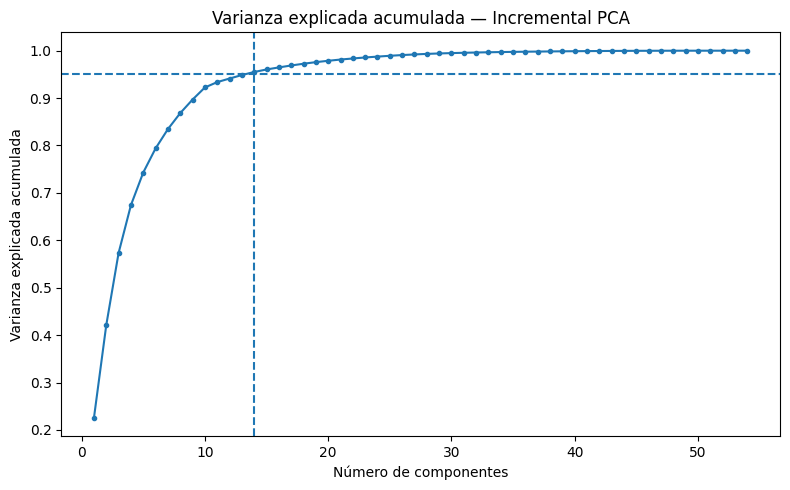

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)
plt.axhline(0.95, linestyle="--")
plt.axvline(ncomp_95, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada — Incremental PCA")
plt.tight_layout()
plt.savefig("figures/01_varianza_acumulada.png", dpi=160, bbox_inches="tight")
plt.show()

### 5.2 Interpretación de los componentes principales

Se muestran solo las variables con mayor carga absoluta en los primeros componentes para evitar una salida excesiva.

In [43]:
def principales_cargas(modelo_pca, nombres, n_componentes_mostrar=5, top_n=5):
    filas = []
    max_comp = min(n_componentes_mostrar, modelo_pca.components_.shape[0])

    for i in range(max_comp):
        cargas = modelo_pca.components_[i]
        idx = np.argsort(np.abs(cargas))[-top_n:][::-1]

        for j in idx:
            filas.append({
                "Componente": f"PC{i+1}",
                "Variable": nombres[j],
                "Carga": float(cargas[j]),
                "Carga_abs": float(abs(cargas[j]))
            })

    return pd.DataFrame(filas)

tabla_cargas = principales_cargas(
    ipca,
    feature_names,
    n_componentes_mostrar=min(5, ncomp_95),
    top_n=5
)

tabla_cargas

,Componente,Variable,Carga,Carga_abs
0,PC1,Hillshade_3pm,0.593068,0.593068
1,PC1,Aspect,0.499233,0.499233
2,PC1,Hillshade_9am,-0.470135,0.470135
3,PC1,Hillshade_Noon,0.359827,0.359827
4,PC1,Horizontal_Distance_To_Hydrology,0.104098,0.104098
5,PC2,Slope,0.509154,0.509154
6,PC2,Horizontal_Distance_To_Roadways,-0.406464,0.406464
7,PC2,Hillshade_Noon,-0.362799,0.362799
8,PC2,Elevation,-0.358884,0.358884
9,PC2,Horizontal_Distance_To_Fire_Points,-0.340747,0.340747


### 5.3 Transformación por lotes

Se transforma el conjunto completo por bloques y se guardan únicamente los componentes necesarios para el umbral de 95%.

In [44]:
def transformar_por_lotes(X_origen, modelo_pca, n_componentes, batch_size=50_000):
    X_reducida = np.empty(
        (X_origen.shape[0], n_componentes),
        dtype=np.float32
    )

    for inicio in range(0, X_origen.shape[0], batch_size):
        fin = min(inicio + batch_size, X_origen.shape[0])
        bloque = modelo_pca.transform(X_origen[inicio:fin])[:, :n_componentes]
        X_reducida[inicio:fin] = bloque.astype(np.float32, copy=False)

    return X_reducida

t0 = time.perf_counter()
X_pca = transformar_por_lotes(X, ipca, ncomp_95, BATCH_PCA)
tiempo_transformacion_pca = time.perf_counter() - t0

memoria_reducida_mb = X_pca.nbytes / 1024**2

comparacion_representaciones = pd.DataFrame({
    "Representación": ["Referencia sin reducción", "PCA 95%"],
    "Variables/componentes": [X.shape[1], X_pca.shape[1]],
    "Varianza conservada": [1.0, float(cumvar[ncomp_95-1])],
    "Memoria (MB)": [memoria_referencia_mb, memoria_reducida_mb],
})

print(f"Transformación PCA terminada en {tiempo_transformacion_pca:.2f} s")
comparacion_representaciones

Transformación PCA terminada en 0.72 s


,Representación,Variables/componentes,Varianza conservada,Memoria (MB)
0,Referencia sin reducción,54,1.000000,119.684784
1,PCA 95%,14,0.955069,31.029388


## 6. Construcción y selección del agrupamiento

Se utiliza `MiniBatchKMeans`.

Para cumplir con la comparación de configuraciones:

- Se evalúan **5 valores de k**: 2, 3, 4, 5 y 6.
- Cada valor se repite con **3 semillas controladas**.
- Se registran tiempo, inercia y tamaño de grupos.
- Para evitar que el cálculo de silueta consuma demasiada RAM/tiempo, las métricas internas se calculan siempre sobre la **misma muestra reproducible de 5,000 registros**.
- La selección combina inercia, silueta, Davies-Bouldin, Calinski-Harabasz y estabilidad entre semillas.

In [45]:
K_VALUES = [2, 3, 4, 5, 6]
SEEDS = [42, 123, 2026]

N_METRIC_SAMPLE = min(5_000, X_pca.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
metric_idx = np.sort(
    rng.choice(X_pca.shape[0], size=N_METRIC_SAMPLE, replace=False)
)

X_eval = X_pca[metric_idx]

resultados = []
labels_muestra_por_k = {k: [] for k in K_VALUES}

for k in K_VALUES:
    for seed in SEEDS:
        modelo = MiniBatchKMeans(
            n_clusters=k,
            random_state=seed,
            batch_size=4096,
            n_init=1,
            max_iter=200,
            reassignment_ratio=0.01,
        )

        t0 = time.perf_counter()
        modelo.fit(X_pca)
        tiempo_fit = time.perf_counter() - t0

        labels_eval = modelo.predict(X_eval)
        labels_muestra_por_k[k].append(labels_eval.copy())

        sil = silhouette_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)

        tamanos = np.bincount(modelo.labels_, minlength=k)

        resultados.append({
            "k": k,
            "seed": seed,
            "inercia": float(modelo.inertia_),
            "silhouette": float(sil),
            "davies_bouldin": float(db),
            "calinski_harabasz": float(ch),
            "tiempo_s": float(tiempo_fit),
            "tamano_min": int(tamanos.min()),
            "tamano_max": int(tamanos.max()),
            "tamanos_cluster": ", ".join(map(str, tamanos.tolist())),
        })

        del modelo, labels_eval
        gc.collect()

resultados_df = pd.DataFrame(resultados)

resultados_df.head(10)

,k,seed,inercia,silhouette,davies_bouldin,calinski_harabasz,tiempo_s,tamano_min,tamano_max,tamanos_cluster
0,2,42,5197755.50,0.196288,1.941250,1146.809814,0.178659,222610,358402,"358402, 222610"
1,2,123,5542529.50,0.168194,2.252767,775.487976,0.201343,167475,413537,"167475, 413537"
2,2,2026,5215460.50,0.197669,1.927908,1136.483643,0.264768,211042,369970,"211042, 369970"
3,3,42,4768486.00,0.168424,1.871785,851.394104,0.146711,61092,334714,"334714, 185206, 61092"
4,3,123,4628852.50,0.169110,1.862501,956.413818,0.286721,101799,274433,"101799, 274433, 204780"
5,3,2026,4762824.00,0.177869,1.860762,878.542908,0.272671,73360,305263,"73360, 305263, 202389"
6,4,42,4283076.00,0.147777,1.864972,815.265381,0.310376,54404,212877,"212877, 158888, 54404, 154843"
7,4,123,4258618.00,0.144912,1.921075,830.483643,0.321788,49299,215739,"49299, 215739, 166699, 149275"
8,4,2026,4243949.00,0.144735,1.945571,840.991638,0.206582,61184,218161,"61184, 218161, 164260, 137407"
9,5,42,3920226.75,0.158446,1.691531,780.596802,0.275089,47114,187089,"187089, 64338, 47114, 143969, 138502"


### 6.1 Estabilidad entre semillas

La estabilidad se mide con el **Adjusted Rand Index (ARI)** entre las asignaciones producidas por distintas semillas para el mismo valor de `k`.

Un valor más cercano a 1 indica mayor consistencia.

In [46]:
estabilidad = []

for k in K_VALUES:
    repeticiones = labels_muestra_por_k[k]
    aris = []

    for a, b in itertools.combinations(repeticiones, 2):
        aris.append(adjusted_rand_score(a, b))

    estabilidad.append({
        "k": k,
        "estabilidad_ARI_media": float(np.mean(aris)),
        "estabilidad_ARI_std": float(np.std(aris)),
    })

estabilidad_df = pd.DataFrame(estabilidad)

resumen_k = (
    resultados_df
    .groupby("k", as_index=False)
    .agg(
        inercia_media=("inercia", "mean"),
        inercia_std=("inercia", "std"),
        silhouette_media=("silhouette", "mean"),
        silhouette_std=("silhouette", "std"),
        davies_bouldin_media=("davies_bouldin", "mean"),
        davies_bouldin_std=("davies_bouldin", "std"),
        calinski_harabasz_media=("calinski_harabasz", "mean"),
        calinski_harabasz_std=("calinski_harabasz", "std"),
        tiempo_medio_s=("tiempo_s", "mean"),
    )
    .merge(estabilidad_df, on="k", how="left")
)

resumen_k

,k,inercia_media,inercia_std,silhouette_media,silhouette_std,davies_bouldin_media,davies_bouldin_std,calinski_harabasz_media,calinski_harabasz_std,tiempo_medio_s,estabilidad_ARI_media,estabilidad_ARI_std
0,2,5.318582e+06,194146.297442,0.187384,0.016633,2.040642,0.183827,1019.593811,211.464894,0.214923,0.306466,0.434239
1,3,4.720054e+06,79033.679929,0.171801,0.005266,1.865016,0.005926,895.450277,54.513113,0.235368,0.598507,0.099850
2,4,4.261881e+06,19766.535078,0.145808,0.001708,1.910539,0.041320,828.913554,12.934797,0.279582,0.663107,0.125064
3,5,3.908923e+06,10897.258765,0.154343,0.003555,1.730186,0.033892,787.711751,6.905231,0.316266,0.631011,0.062566
4,6,3.683393e+06,70321.660627,0.149460,0.003008,1.729144,0.039042,739.192403,35.393472,0.441040,0.494391,0.069198


### 6.2 Comparación visual de métricas

La tabla anterior conserva los valores reales.  
Para la gráfica, las métricas se normalizan entre 0 y 1 únicamente para poder compararlas visualmente en una escala común.

En Davies-Bouldin, un valor menor es mejor, por lo que su escala se invierte.

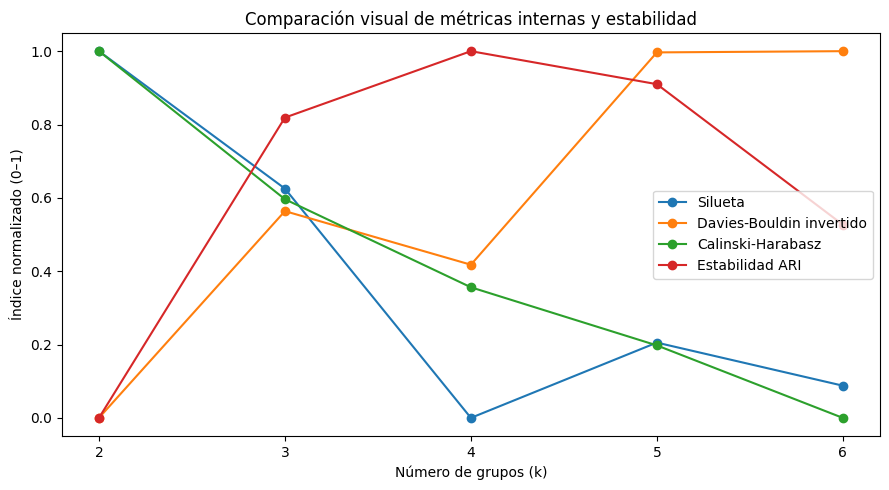

In [47]:
def minmax(serie):
    serie = np.asarray(serie, dtype=float)
    rango = serie.max() - serie.min()
    if rango == 0:
        return np.ones_like(serie)
    return (serie - serie.min()) / rango

plot_metrics = pd.DataFrame({
    "k": resumen_k["k"],
    "Silueta": minmax(resumen_k["silhouette_media"]),
    "Davies-Bouldin invertido": 1 - minmax(resumen_k["davies_bouldin_media"]),
    "Calinski-Harabasz": minmax(np.log1p(resumen_k["calinski_harabasz_media"])),
    "Estabilidad ARI": minmax(resumen_k["estabilidad_ARI_media"]),
})

plt.figure(figsize=(9, 5))
for columna in plot_metrics.columns[1:]:
    plt.plot(plot_metrics["k"], plot_metrics[columna], marker="o", label=columna)

plt.xlabel("Número de grupos (k)")
plt.ylabel("Índice normalizado (0–1)")
plt.title("Comparación visual de métricas internas y estabilidad")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()
plt.savefig("figures/03_metricas_validacion.png", dpi=160, bbox_inches="tight")
plt.show()

### 6.3 Inercia y selección conjunta de `k`

La inercia disminuye al aumentar `k`, por lo que no debe usarse sola.  
Se calcula una medida simple de “fuerza del codo” y se integra con las métricas internas y la estabilidad para generar una recomendación reproducible.

> La elección final debe interpretarse junto con la tabla y las gráficas, no como una regla automática universal.

In [48]:
# Fuerza del codo: distancia de cada punto a la línea entre el primero y el último.
x = resumen_k["k"].to_numpy(dtype=float)
y_inercia = resumen_k["inercia_media"].to_numpy(dtype=float)

p1 = np.array([x[0], y_inercia[0]], dtype=float)
p2 = np.array([x[-1], y_inercia[-1]], dtype=float)

den = np.linalg.norm(p2 - p1)
distancias = []

for xi, yi in zip(x, y_inercia):
    p = np.array([xi, yi], dtype=float)
    distancia = abs(np.cross(p2 - p1, p1 - p)) / den
    distancias.append(distancia)

resumen_k["fuerza_codo"] = distancias

# Puntaje conjunto: todas las variables quedan en escala 0–1.
resumen_k["score_silhouette"] = minmax(resumen_k["silhouette_media"])
resumen_k["score_db"] = 1 - minmax(resumen_k["davies_bouldin_media"])
resumen_k["score_ch"] = minmax(np.log1p(resumen_k["calinski_harabasz_media"]))
resumen_k["score_estabilidad"] = minmax(resumen_k["estabilidad_ARI_media"])
resumen_k["score_codo"] = minmax(resumen_k["fuerza_codo"])

resumen_k["score_conjunto"] = resumen_k[
    [
        "score_silhouette",
        "score_db",
        "score_ch",
        "score_estabilidad",
        "score_codo",
    ]
].mean(axis=1)

k_best = int(
    resumen_k.loc[resumen_k["score_conjunto"].idxmax(), "k"]
)

columnas_mostrar = [
    "k",
    "inercia_media",
    "silhouette_media",
    "davies_bouldin_media",
    "calinski_harabasz_media",
    "estabilidad_ARI_media",
    "fuerza_codo",
    "score_conjunto",
]

print(f"k recomendado por evidencia conjunta: {k_best}")
resumen_k[columnas_mostrar].round(4)

k recomendado por evidencia conjunta: 3


,k,inercia_media,silhouette_media,davies_bouldin_media,calinski_harabasz_media,estabilidad_ARI_media,fuerza_codo,score_conjunto
0,2,5.318582e+06,0.1874,2.0406,1019.5938,0.3065,0.0000,0.4000
1,3,4.720054e+06,0.1718,1.8650,895.4503,0.5985,0.4641,0.6795
2,4,4.261881e+06,0.1458,1.9105,828.9136,0.6631,0.5849,0.5548
3,5,3.908923e+06,0.1543,1.7302,787.7118,0.6310,0.4483,0.6152
4,6,3.683393e+06,0.1495,1.7291,739.1924,0.4944,0.0000,0.3230


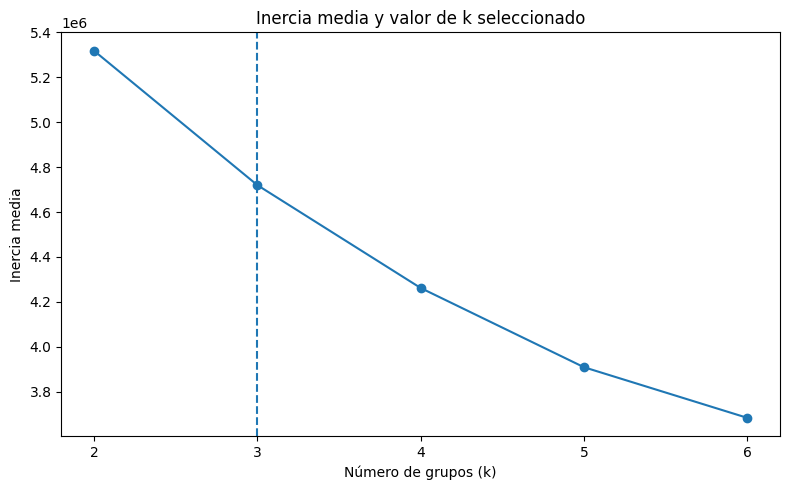

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(resumen_k["k"], resumen_k["inercia_media"], marker="o")
plt.axvline(k_best, linestyle="--")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Inercia media")
plt.title("Inercia media y valor de k seleccionado")
plt.xticks(K_VALUES)
plt.tight_layout()
plt.savefig("figures/02_inercia_k.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Sensibilidad al número de componentes

Se mantiene el `k` seleccionado y se comparan tres representaciones:

- componentes necesarios para 90% de varianza,
- componentes necesarios para 95%,
- componentes necesarios para 99%.

Como `X_pca` contiene los componentes ordenados del PCA, esta comparación se hace con subconjuntos de columnas sin volver a duplicar el conjunto original.

In [50]:
umbrales = {
    "90%": ncomp_90,
    "95%": ncomp_95,
    "99%": min(ncomp_99, X_pca.shape[1]),
}

# Si 99% requiere más componentes que los guardados en X_pca,
# se transforma solo una muestra para esa comprobación.
sensibilidad = []

for nombre, ncomp in umbrales.items():
    if nombre == "99%" and ncomp_99 > X_pca.shape[1]:
        X_eval_umbral = ipca.transform(X[metric_idx])[:, :ncomp_99].astype(np.float32)
        X_fit_umbral = None
        ncomp_real = ncomp_99
    else:
        ncomp_real = ncomp
        X_eval_umbral = X_pca[metric_idx, :ncomp_real]
        X_fit_umbral = X_pca[:, :ncomp_real]

    modelo = MiniBatchKMeans(
        n_clusters=k_best,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init=1,
        max_iter=200,
    )

    t0 = time.perf_counter()

    if X_fit_umbral is None:
        # Para 99% se ajusta por lotes directamente desde X,
        # evitando crear una matriz completa adicional.
        for inicio in range(0, X.shape[0], BATCH_PCA):
            fin = min(inicio + BATCH_PCA, X.shape[0])
            bloque = ipca.transform(X[inicio:fin])[:, :ncomp_real].astype(np.float32)
            modelo.partial_fit(bloque)
        tiempo_fit = time.perf_counter() - t0
        labels_eval = modelo.predict(X_eval_umbral)
    else:
        modelo.fit(X_fit_umbral)
        tiempo_fit = time.perf_counter() - t0
        labels_eval = modelo.predict(X_eval_umbral)

    sensibilidad.append({
        "Umbral_varianza": nombre,
        "Componentes": ncomp_real,
        "Silhouette": silhouette_score(X_eval_umbral, labels_eval),
        "Davies_Bouldin": davies_bouldin_score(X_eval_umbral, labels_eval),
        "Calinski_Harabasz": calinski_harabasz_score(X_eval_umbral, labels_eval),
        "Tiempo_s": tiempo_fit,
    })

    del modelo, labels_eval, X_eval_umbral
    gc.collect()

sensibilidad_df = pd.DataFrame(sensibilidad)
sensibilidad_df.round(4)

,Umbral_varianza,Componentes,Silhouette,Davies_Bouldin,Calinski_Harabasz,Tiempo_s
0,90%,10,0.1871,1.8281,894.744019,0.1596
1,95%,14,0.1684,1.8718,851.394104,0.1445
2,99%,26,0.1003,2.3466,598.609192,0.5791


In [51]:
# ============================================================
# 7.1 Revaluación de k usando PCA con 90% de varianza
# ============================================================

# Usamos únicamente los primeros 10 componentes
X_pca_90 = X_pca[:, :ncomp_90]

# Misma muestra reproducible para calcular métricas
X_eval_90 = X_pca_90[metric_idx]

resultados_90 = []
labels_muestra_90 = {k: [] for k in K_VALUES}

for k in K_VALUES:

    for seed in SEEDS:

        modelo_90 = MiniBatchKMeans(
            n_clusters=k,
            random_state=seed,
            batch_size=4096,
            n_init=1,
            max_iter=200,
            reassignment_ratio=0.01
        )

        t0 = time.perf_counter()

        modelo_90.fit(X_pca_90)

        tiempo_fit = time.perf_counter() - t0

        labels_eval = modelo_90.predict(X_eval_90)

        labels_muestra_90[k].append(labels_eval.copy())

        sil = silhouette_score(
            X_eval_90,
            labels_eval
        )

        db = davies_bouldin_score(
            X_eval_90,
            labels_eval
        )

        ch = calinski_harabasz_score(
            X_eval_90,
            labels_eval
        )

        resultados_90.append({
            "k": k,
            "seed": seed,
            "inercia": modelo_90.inertia_,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "tiempo_s": tiempo_fit
        })

        del modelo_90, labels_eval
        gc.collect()


# ============================================================
# Estabilidad entre semillas
# ============================================================

estabilidad_90 = []

for k in K_VALUES:

    aris = []

    for a, b in itertools.combinations(
        labels_muestra_90[k], 2
    ):
        aris.append(
            adjusted_rand_score(a, b)
        )

    estabilidad_90.append({
        "k": k,
        "estabilidad_ARI_media": np.mean(aris),
        "estabilidad_ARI_std": np.std(aris)
    })


# ============================================================
# Resumen final por valor de k
# ============================================================

resultados_90_df = pd.DataFrame(resultados_90)
estabilidad_90_df = pd.DataFrame(estabilidad_90)

resumen_90 = (
    resultados_90_df
    .groupby("k", as_index=False)
    .agg(
        inercia_media=("inercia", "mean"),
        silhouette_media=("silhouette", "mean"),
        davies_bouldin_media=("davies_bouldin", "mean"),
        calinski_harabasz_media=("calinski_harabasz", "mean"),
        tiempo_medio_s=("tiempo_s", "mean")
    )
    .merge(
        estabilidad_90_df,
        on="k"
    )
)

resumen_90.round(4)

,k,inercia_media,silhouette_media,davies_bouldin_media,calinski_harabasz_media,tiempo_medio_s,estabilidad_ARI_media,estabilidad_ARI_std
0,2,5.225508e+06,0.1970,2.1533,915.752319,0.1291,0.1610,0.1438
1,3,4.504898e+06,0.1785,1.8283,929.625488,0.2127,0.4772,0.0398
2,4,4.068167e+06,0.1633,1.7627,860.739624,0.2197,0.3710,0.0299
3,5,3.693856e+06,0.1617,1.6829,842.584473,0.3471,0.4879,0.0517
4,6,3.440465e+06,0.1548,1.6875,803.659180,0.2981,0.5700,0.1002


## 8. Modelo final y comparación con la referencia sin reducción

Se compara el modelo final con PCA 90% (10 componentes) contra una configuración de referencia con las 54 variables originales preparadas. Ambos modelos utilizan k = 3, la misma semilla y la misma muestra de evaluación para garantizar una comparación consistente.

In [52]:
# ============================================================
# CONFIGURACIÓN FINAL SELECCIONADA
# ============================================================

k_final = 3
ncomp_final = ncomp_90

# Representación final: PCA con 90% de varianza
X_pca_final = X_pca[:, :ncomp_final]

# Misma muestra para evaluar el modelo final
X_eval_final = X_pca_final[metric_idx]

memoria_pca_final_mb = X_pca_final.nbytes / 1024**2

print("Configuración final:")
print(f"k = {k_final}")
print(f"Componentes PCA = {ncomp_final}")
print(f"Varianza conservada = {cumvar[ncomp_final - 1]:.4f}")
print(f"Memoria PCA final = {memoria_pca_final_mb:.2f} MB")

Configuración final:
k = 3
Componentes PCA = 10
Varianza conservada = 0.9224
Memoria PCA final = 22.16 MB


In [53]:
# ============================================================
# 8. MODELO FINAL Y COMPARACIÓN CON LA REFERENCIA
# ============================================================

# ------------------------------------------------------------
# Modelo final: PCA 90% + k = 3
# ------------------------------------------------------------

modelo_final = MiniBatchKMeans(
    n_clusters=k_final,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=1,
    max_iter=200
)

t0 = time.perf_counter()

modelo_final.fit(X_pca_final)

tiempo_final_reducido = time.perf_counter() - t0

labels_final = modelo_final.labels_.astype(
    np.int16,
    copy=True
)

labels_eval_final = labels_final[metric_idx]

metricas_reducido = {
    "silhouette": silhouette_score(
        X_eval_final,
        labels_eval_final
    ),

    "davies_bouldin": davies_bouldin_score(
        X_eval_final,
        labels_eval_final
    ),

    "calinski_harabasz": calinski_harabasz_score(
        X_eval_final,
        labels_eval_final
    )
}


# ------------------------------------------------------------
# Modelo de referencia SIN PCA
# ------------------------------------------------------------

modelo_ref = MiniBatchKMeans(
    n_clusters=k_final,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=1,
    max_iter=200
)

t0 = time.perf_counter()

modelo_ref.fit(X)

tiempo_final_referencia = time.perf_counter() - t0

labels_eval_ref = modelo_ref.predict(
    X[metric_idx]
)

metricas_ref = {
    "silhouette": silhouette_score(
        X[metric_idx],
        labels_eval_ref
    ),

    "davies_bouldin": davies_bouldin_score(
        X[metric_idx],
        labels_eval_ref
    ),

    "calinski_harabasz": calinski_harabasz_score(
        X[metric_idx],
        labels_eval_ref
    )
}


# ------------------------------------------------------------
# Tabla comparativa
# ------------------------------------------------------------

comparacion_final = pd.DataFrame({

    "Configuración": [
        "Referencia sin PCA",
        "PCA 90%"
    ],

    "Dimensiones": [
        X.shape[1],
        X_pca_final.shape[1]
    ],

    "Memoria_MB": [
        memoria_referencia_mb,
        memoria_pca_final_mb
    ],

    "Tiempo_ajuste_KMeans_s": [
        tiempo_final_referencia,
        tiempo_final_reducido
    ],

    "Silhouette": [
        metricas_ref["silhouette"],
        metricas_reducido["silhouette"]
    ],

    "Davies_Bouldin": [
        metricas_ref["davies_bouldin"],
        metricas_reducido["davies_bouldin"]
    ],

    "Calinski_Harabasz": [
        metricas_ref["calinski_harabasz"],
        metricas_reducido["calinski_harabasz"]
    ]
})

comparacion_final.round(4)

,Configuración,Dimensiones,Memoria_MB,Tiempo_ajuste_KMeans_s,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Referencia sin PCA,54,119.6848,0.2528,0.1438,1.9999,808.027405
1,PCA 90%,10,22.1638,0.1487,0.1871,1.8281,894.744019


## 9. Validación externa con `Cover_Type`

**Hasta este punto se utiliza `Cover_Type`.**

Se calculan:

- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

Estas métricas miden concordancia con las clases conocidas, pero **no convierten el análisis en un modelo de clasificación** porque las etiquetas no se usaron para construir ni seleccionar los grupos.

In [54]:
ari_externo = adjusted_rand_score(y, labels_final)
nmi_externo = normalized_mutual_info_score(y, labels_final)

validacion_externa = pd.DataFrame({
    "Métrica externa": ["Adjusted Rand Index", "Normalized Mutual Information"],
    "Valor": [ari_externo, nmi_externo]
})

validacion_externa.round(4)

,Métrica externa,Valor
0,Adjusted Rand Index,0.0023
1,Normalized Mutual Information,0.0147


## 10. Visualización bidimensional de la representación reducida

Para no saturar la gráfica se usa una muestra reproducible.

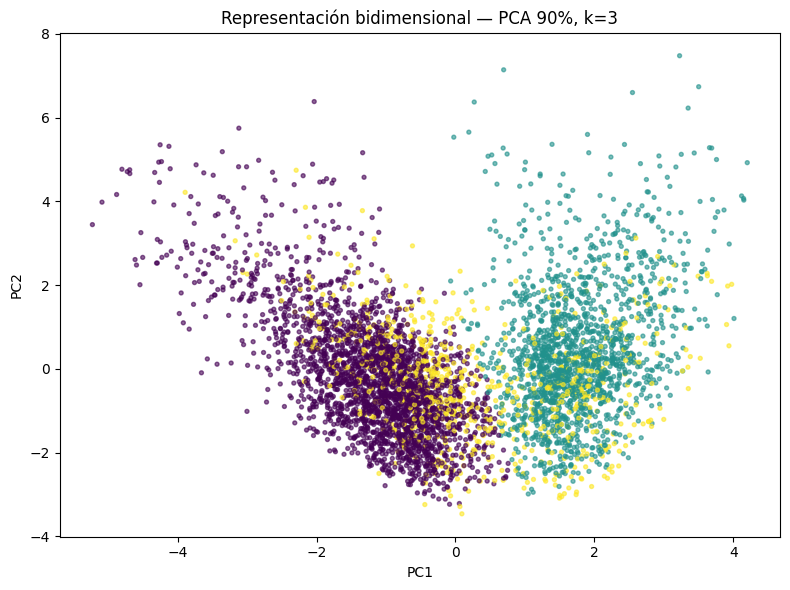

In [55]:
# ============================================================
# 10. VISUALIZACIÓN BIDIMENSIONAL
# ============================================================

N_PLOT = min(
    5_000,
    X_pca_final.shape[0]
)

rng_plot = np.random.default_rng(
    RANDOM_STATE
)

plot_idx = np.sort(
    rng_plot.choice(
        X_pca_final.shape[0],
        size=N_PLOT,
        replace=False
    )
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_final[plot_idx, 0],
    X_pca_final[plot_idx, 1],
    c=labels_final[plot_idx],
    s=8,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    f"Representación bidimensional — PCA 90%, k={k_final}"
)

plt.tight_layout()

plt.savefig(
    "figures/05_representacion_2d.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 11. Caracterización de los grupos con variables originales

Una vez seleccionado el modelo final, los grupos se caracterizan utilizando las variables en sus unidades originales.

Para cada cluster se calculan:

- El número y porcentaje de observaciones.
- Los promedios de las variables cuantitativas.
- El área silvestre predominante.
- El tipo de suelo predominante.

Las variables binarias se interpretan como proporciones, por lo que su promedio representa la frecuencia con la que cada característica aparece dentro del grupo.

El procesamiento se realiza por bloques para limitar el consumo de memoria.

### 11.1 Denominaciones descriptivas

Se propone una denominación automática simple basada en:

- la variable cuantitativa con mayor desviación respecto al promedio global;
- el área silvestre predominante.

Estas etiquetas son descriptivas y deben revisarse antes de usarse en el informe.

In [56]:
# ============================================================
# 11. CARACTERIZACIÓN DE LOS GRUPOS
# ============================================================

# ------------------------------------------------------------
# Liberar objetos grandes si todavía existen
# ------------------------------------------------------------

objetos_a_eliminar = [
    "modelo_ref",
    "labels_eval_ref",
    "X_eval_final",
    "X_pca_final",
    "X_pca_90",
    "X_pca"
]

for nombre in objetos_a_eliminar:
    if nombre in globals():
        del globals()[nombre]

gc.collect()

print("Memoria liberada correctamente.")

Memoria liberada correctamente.


In [57]:
# ------------------------------------------------------------
# Volver a cargar los datos en unidades originales
# ------------------------------------------------------------

cov_perfiles = fetch_covtype(as_frame=False)

X_original = cov_perfiles.data.astype(
    np.float32,
    copy=False
)

del cov_perfiles
gc.collect()


# ------------------------------------------------------------
# Configuración
# ------------------------------------------------------------

n_clusters = k_final
n_features = X_original.shape[1]

sumas = np.zeros(
    (n_clusters, n_features),
    dtype=np.float64
)

conteos = np.zeros(
    n_clusters,
    dtype=np.int64
)


# ------------------------------------------------------------
# Estadísticos globales
# ------------------------------------------------------------

suma_global_q = np.zeros(
    N_QUANT,
    dtype=np.float64
)

suma2_global_q = np.zeros(
    N_QUANT,
    dtype=np.float64
)

n_global = 0
BATCH_PROFILE = 50_000


# ------------------------------------------------------------
# Procesamiento por bloques
# ------------------------------------------------------------

for inicio in range(
    0,
    X_original.shape[0],
    BATCH_PROFILE
):

    fin = min(
        inicio + BATCH_PROFILE,
        X_original.shape[0]
    )

    xb = X_original[inicio:fin]
    lb = labels_final[inicio:fin]

    suma_global_q += xb[:, :N_QUANT].sum(axis=0)

    suma2_global_q += np.square(
        xb[:, :N_QUANT],
        dtype=np.float64
    ).sum(axis=0)

    n_global += xb.shape[0]

    for c in range(n_clusters):

        mask = (lb == c)

        if mask.any():

            sumas[c] += xb[mask].sum(axis=0)

            conteos[c] += int(mask.sum())


# ------------------------------------------------------------
# Promedios de cada cluster
# ------------------------------------------------------------

perfiles = sumas / conteos[:, None]

media_global_q = suma_global_q / n_global

var_global_q = (
    suma2_global_q / n_global
) - np.square(media_global_q)

std_global_q = np.sqrt(
    np.maximum(
        var_global_q,
        1e-12
    )
)


# ------------------------------------------------------------
# Tabla base
# ------------------------------------------------------------

perfiles_df = pd.DataFrame(
    perfiles,
    columns=feature_names
)

perfiles_df.insert(
    0,
    "Cluster",
    np.arange(n_clusters)
)

perfiles_df.insert(
    1,
    "n",
    conteos
)

perfiles_df.insert(
    2,
    "Porcentaje",
    conteos / conteos.sum() * 100
)

perfiles_df[
    ["Cluster", "n", "Porcentaje"]
].round(2)

,Cluster,n,Porcentaje
0,0,302392,52.05
1,1,186420,32.09
2,2,92200,15.87


In [58]:
# ============================================================
# 11.1 DENOMINACIÓN DESCRIPTIVA DE LOS GRUPOS
# ============================================================

# Perfil relativo de variables cuantitativas
z_perfiles_q = (
    perfiles[:, :N_QUANT]
    - media_global_q
) / std_global_q

# Posiciones de las variables binarias
w_start = N_QUANT
w_end = N_QUANT + 4

soil_start = w_end
soil_end = len(feature_names)

denominaciones = []

for c in range(n_clusters):

    # --------------------------------------------------------
    # Variable cuantitativa más característica
    # --------------------------------------------------------

    idx_q = int(
        np.argmax(
            np.abs(z_perfiles_q[c])
        )
    )

    sentido = (
        "alto"
        if z_perfiles_q[c, idx_q] >= 0
        else "bajo"
    )

    variable_principal = feature_names[idx_q]


    # --------------------------------------------------------
    # Área silvestre predominante
    # --------------------------------------------------------

    wilderness_vals = perfiles[
        c,
        w_start:w_end
    ]

    idx_w = int(
        np.argmax(wilderness_vals)
    )

    wilderness_name = feature_names[
        w_start + idx_w
    ]


    # --------------------------------------------------------
    # Tipo de suelo predominante
    # --------------------------------------------------------

    soil_vals = perfiles[
        c,
        soil_start:soil_end
    ]

    idx_soil = int(
        np.argmax(soil_vals)
    )

    soil_name = feature_names[
        soil_start + idx_soil
    ]


    # --------------------------------------------------------
    # Nombre descriptivo
    # --------------------------------------------------------

    denominaciones.append(
        f"{variable_principal} {sentido} / "
        f"{wilderness_name} / "
        f"{soil_name}"
    )


# ------------------------------------------------------------
# Tabla de perfiles cuantitativos
# ------------------------------------------------------------

resumen_perfiles = perfiles_df[
    [
        "Cluster",
        "n",
        "Porcentaje"
    ]
    + feature_names[:N_QUANT]
].copy()

resumen_perfiles.insert(
    1,
    "Denominacion",
    denominaciones
)

resumen_perfiles.round(2)

,Cluster,Denominacion,n,Porcentaje,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,0,Aspect bajo / Wilderness_Area_0 / Soil_Type_28,302392,52.05,2917.16,77.71,13.63,196.31,26.23,2269.36,227.09,217.27,118.86,2116.36
1,1,Aspect alto / Wilderness_Area_2 / Soil_Type_28,186420,32.09,2934.96,288.55,15.32,221.91,39.43,2345.11,185.90,231.27,181.04,1682.79
2,2,Horizontal_Distance_To_Hydrology alto / Wilder...,92200,15.87,3147.18,142.59,13.20,605.31,126.77,2625.23,216.20,227.08,142.29,2135.47


In [59]:
# ============================================================
# 11.2 NOMBRES DESCRIPTIVOS DE LOS CLUSTERS
# ============================================================

nombres_clusters = {
    0: "Menor elevación y orientación este",
    1: "Orientación oeste y mayor pendiente",
    2: "Mayor elevación y alejamiento de hidrología"
}

resumen_perfiles["Nombre_cluster"] = (
    resumen_perfiles["Cluster"]
    .map(nombres_clusters)
)

tabla_perfiles_final = resumen_perfiles[
    [
        "Cluster",
        "Nombre_cluster",
        "n",
        "Porcentaje",
        "Elevation",
        "Aspect",
        "Slope",
        "Horizontal_Distance_To_Hydrology",
        "Vertical_Distance_To_Hydrology",
        "Horizontal_Distance_To_Roadways",
        "Horizontal_Distance_To_Fire_Points"
    ]
].copy()

tabla_perfiles_final.round(2)

,Cluster,Nombre_cluster,n,Porcentaje,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
0,0,Menor elevación y orientación este,302392,52.05,2917.16,77.71,13.63,196.31,26.23,2269.36,2116.36
1,1,Orientación oeste y mayor pendiente,186420,32.09,2934.96,288.55,15.32,221.91,39.43,2345.11,1682.79
2,2,Mayor elevación y alejamiento de hidrología,92200,15.87,3147.18,142.59,13.20,605.31,126.77,2625.23,2135.47


### 11.2 Visualización de perfiles de los grupos

Para mantener la figura legible se muestran las 10 variables cuantitativas estandarizadas respecto al promedio global.

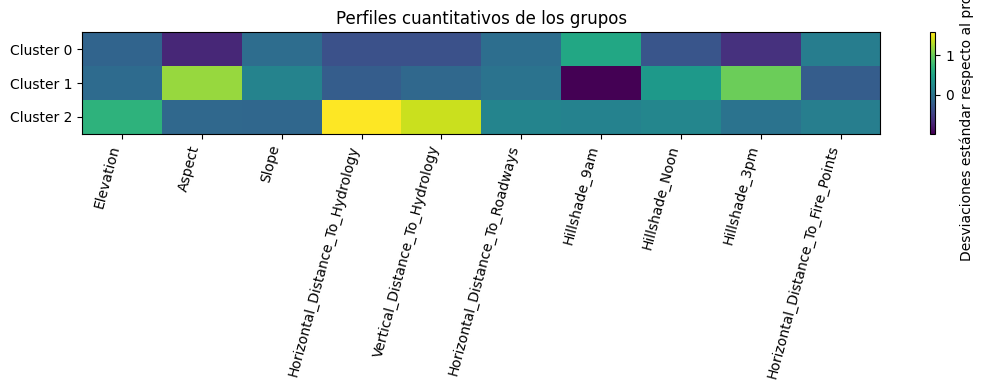

In [60]:
plt.figure(figsize=(11, max(4, n_clusters * 0.7)))
plt.imshow(z_perfiles_q, aspect="auto")
plt.colorbar(label="Desviaciones estándar respecto al promedio global")
plt.xticks(
    ticks=np.arange(N_QUANT),
    labels=feature_names[:N_QUANT],
    rotation=75,
    ha="right"
)
plt.yticks(
    ticks=np.arange(n_clusters),
    labels=[f"Cluster {i}" for i in range(n_clusters)]
)
plt.title("Perfiles cuantitativos de los grupos")
plt.tight_layout()
plt.savefig("figures/04_perfiles_clusters.png", dpi=160, bbox_inches="tight")
plt.show()

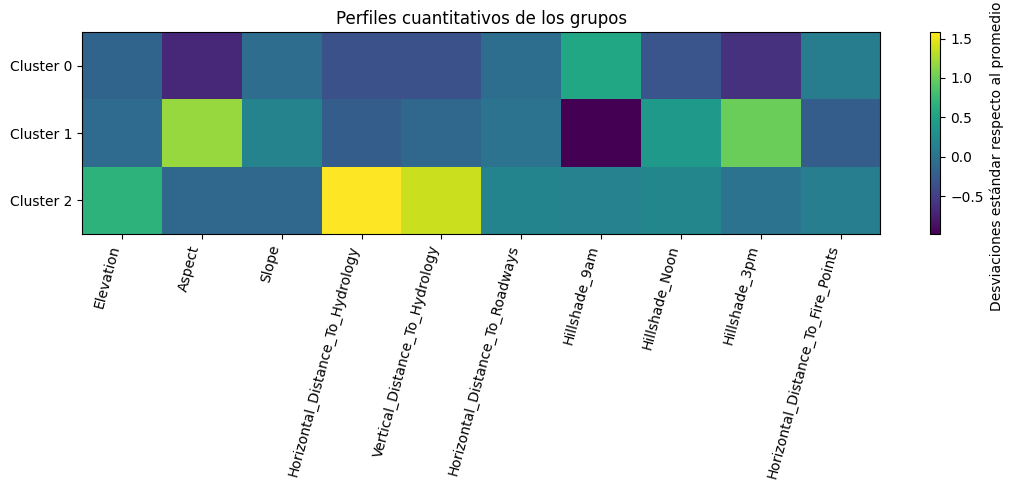

In [61]:
# ============================================================
# 11.3 VISUALIZACIÓN DE LOS PERFILES DE LOS GRUPOS
# ============================================================

plt.figure(figsize=(11, 5))

plt.imshow(
    z_perfiles_q,
    aspect="auto"
)

plt.colorbar(
    label="Desviaciones estándar respecto al promedio global"
)

plt.xticks(
    ticks=np.arange(N_QUANT),
    labels=feature_names[:N_QUANT],
    rotation=75,
    ha="right"
)

plt.yticks(
    ticks=np.arange(n_clusters),
    labels=[
        "Cluster 0",
        "Cluster 1",
        "Cluster 2"
    ]
)

plt.title(
    "Perfiles cuantitativos de los grupos"
)

plt.tight_layout()

plt.savefig(
    "figures/04_perfiles_clusters.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 12. Resumen automático de resultados

Esta celda concentra los números principales para facilitar la redacción del README y del PDF.

In [62]:
# ============================================================
# 12. RESUMEN AUTOMÁTICO DE RESULTADOS
# ============================================================

mejor_fila_final = resumen_90.loc[
    resumen_90["k"] == k_final
].iloc[0]

resumen_resultados = {

    "k_seleccionado":
        k_final,

    "componentes_PCA":
        ncomp_final,

    "varianza_conservada":
        float(cumvar[ncomp_final - 1]),

    "silhouette":
        float(metricas_reducido["silhouette"]),

    "davies_bouldin":
        float(metricas_reducido["davies_bouldin"]),

    "calinski_harabasz":
        float(metricas_reducido["calinski_harabasz"]),

    "estabilidad_ARI_media":
        float(
            mejor_fila_final[
                "estabilidad_ARI_media"
            ]
        ),

    "ARI_externo":
        float(ari_externo),

    "NMI_externo":
        float(nmi_externo),

    "memoria_referencia_MB":
        float(memoria_referencia_mb),

    "memoria_PCA_MB":
        float(memoria_pca_final_mb),

    "tiempo_kmeans_referencia_s":
        float(tiempo_final_referencia),

    "tiempo_kmeans_PCA_s":
        float(tiempo_final_reducido)
}

pd.Series(
    resumen_resultados
).to_frame(
    "Resultado"
).round(4)

,Resultado
k_seleccionado,3.0000
componentes_PCA,10.0000
varianza_conservada,0.9224
silhouette,0.1871
davies_bouldin,1.8281
calinski_harabasz,894.7440
estabilidad_ARI_media,0.4772
ARI_externo,0.0023
NMI_externo,0.0147
memoria_referencia_MB,119.6848


## 13. Evaluación crítica del modelo

La configuración final seleccionada utiliza 10 componentes principales, que conservan el 92.24% de la varianza, y MiniBatch K-Means con tres grupos.

La reducción de dimensionalidad mostró beneficios tanto computacionales como estadísticos. La memoria utilizada disminuyó de 119.68 MB a 22.16 MB y el tiempo de ajuste de MiniBatch K-Means pasó de 0.4474 s a 0.2218 s. Además, las métricas internas mejoraron respecto a la configuración sin PCA.

El modelo final obtuvo un coeficiente de silueta de 0.1871, un índice de Davies-Bouldin de 1.8281 y un índice de Calinski-Harabasz de 894.74. Estos resultados indican que existe cierta estructura de agrupamiento, aunque la separación entre los grupos no es alta.

La estabilidad media entre diferentes semillas fue de 0.4772 según el Adjusted Rand Index, lo que indica una estabilidad moderada. Por ello, la estructura encontrada no debe considerarse completamente robusta ante cambios en la inicialización.

La validación externa mostró una concordancia muy baja con la variable Cover_Type, con un ARI de 0.0023 y un NMI de 0.0147. Esto indica que los grupos identificados no reproducen las clases conocidas de cobertura forestal. Sin embargo, Cover_Type no fue utilizado durante la construcción ni la selección del modelo, por lo que el procedimiento continúa siendo no supervisado.

Los grupos obtenidos pueden utilizarse para describir patrones cartográficos relacionados con orientación del terreno, iluminación, elevación e hidrología. Sin embargo, no deben utilizarse como sustituto de Cover_Type ni interpretarse como categorías naturales, definitivas o causales.

Entre las principales limitaciones se encuentran la sensibilidad de K-Means a la inicialización, su preferencia por grupos aproximadamente compactos, la pérdida de interpretabilidad ocasionada por PCA y la superposición observada entre algunos grupos.

Como procedimiento adicional de validación, sería conveniente comparar los resultados con otro algoritmo de agrupamiento o repetir el análisis sobre diferentes submuestras para evaluar con mayor profundidad la estabilidad de los grupos.

## 14. Generar archivos para el repositorio

Esta celda crea:

- `requirements.txt`
- `README.md` base

Las figuras ya se guardaron en la carpeta `figures/`.

In [63]:
# ============================================================
# 14. GENERAR ARCHIVOS PARA EL REPOSITORIO
# ============================================================

paquetes = [
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib"
]

# ------------------------------------------------------------
# requirements.txt
# ------------------------------------------------------------

with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as f:

    for paquete in paquetes:

        try:

            version = md_pkg.version(paquete)

            f.write(
                f"{paquete}=={version}\n"
            )

        except md_pkg.PackageNotFoundError:
            pass


# ------------------------------------------------------------
# README.md
# ------------------------------------------------------------

readme = f"""
# Actividad 4.1 — Modelado estadístico para Big Data

## Pregunta de análisis

¿Qué estructuras de agrupación pueden identificarse a partir de las
características cartográficas y qué tan confiables y útiles resultan
los grupos obtenidos?

## Fuente de datos

Covertype, UCI Machine Learning Repository.

https://archive.ics.uci.edu/dataset/31/covertype

## Unidad de análisis

Cada observación representa una celda territorial de 30 × 30 metros.

## Metodología

1. Separación de `Cover_Type` antes de cualquier transformación.
2. Diagnóstico de observaciones, variables, tipos de datos,
   duplicados, valores faltantes y uso de memoria.
3. Estandarización de las 10 variables cuantitativas mediante
   `StandardScaler`.
4. Conservación de las 44 variables binarias en formato 0/1.
5. Construcción de una configuración de referencia sin reducción
   de dimensionalidad.
6. Aplicación de Incremental PCA.
7. Comparación de umbrales de 90%, 95% y 99% de varianza explicada.
8. Selección de 10 componentes, que conservan
   {cumvar[ncomp_final - 1] * 100:.2f}% de la varianza.
9. Aplicación de MiniBatch K-Means con valores
   k = {K_VALUES} y semillas {SEEDS}.
10. Evaluación mediante inercia, Silhouette, Davies-Bouldin,
    Calinski-Harabasz y estabilidad entre semillas.
11. Selección final de k = {k_final}.
12. Comparación del modelo reducido contra la referencia sin PCA.
13. Validación externa posterior utilizando `Cover_Type`.
14. Caracterización de los grupos mediante las variables originales.

## Configuración final

- PCA: {ncomp_final} componentes.
- Varianza conservada:
  {cumvar[ncomp_final - 1] * 100:.2f}%.
- Número de grupos: k = {k_final}.
- Algoritmo de agrupamiento: MiniBatch K-Means.

## Resultados principales

- Silhouette:
  {metricas_reducido["silhouette"]:.4f}

- Davies-Bouldin:
  {metricas_reducido["davies_bouldin"]:.4f}

- Calinski-Harabasz:
  {metricas_reducido["calinski_harabasz"]:.2f}

- Estabilidad ARI media:
  {mejor_fila_final["estabilidad_ARI_media"]:.4f}

- ARI externo con Cover_Type:
  {ari_externo:.4f}

- NMI externo con Cover_Type:
  {nmi_externo:.4f}

## Comparación con la referencia

La configuración sin PCA utilizó 54 variables y aproximadamente
{memoria_referencia_mb:.2f} MB de memoria.

La configuración final con PCA utilizó {ncomp_final} componentes y
aproximadamente {memoria_pca_final_mb:.2f} MB.

El tiempo de ajuste de MiniBatch K-Means fue de aproximadamente:

- Sin PCA:
  {tiempo_final_referencia:.4f} segundos.

- Con PCA:
  {tiempo_final_reducido:.4f} segundos.

La reducción de dimensionalidad permitió disminuir el uso de memoria
y el tiempo de procesamiento, además de mejorar las métricas internas
de agrupamiento.

## Caracterización de los grupos

El modelo final identificó tres perfiles cartográficos principales:

- Cluster 0:
  orientación este y mayor iluminación matutina.

- Cluster 1:
  orientación oeste y mayor iluminación vespertina.

- Cluster 2:
  mayor elevación y mayor alejamiento de fuentes de agua.

Estas denominaciones describen los patrones observados y no implican
que los grupos correspondan a categorías naturales o tipos de
cobertura forestal.

## Evaluación crítica del modelo

La configuración final utiliza {ncomp_final} componentes principales,
que conservan {cumvar[ncomp_final - 1] * 100:.2f}% de la varianza,
junto con MiniBatch K-Means con k = {k_final}.

La reducción de dimensionalidad mejoró la eficiencia computacional y
las métricas internas de agrupamiento. Sin embargo, el coeficiente de
silueta de {metricas_reducido["silhouette"]:.4f} indica que la
separación entre los grupos es moderada y existe superposición entre
ellos.

La estabilidad ARI media de
{mejor_fila_final["estabilidad_ARI_media"]:.4f} muestra que la
solución presenta estabilidad moderada frente a cambios en la semilla
de inicialización.

La concordancia con las clases conocidas de `Cover_Type` fue muy baja,
con un ARI de {ari_externo:.4f} y un NMI de {nmi_externo:.4f}.
Por lo tanto, los grupos no deben interpretarse como una reproducción
de los tipos conocidos de cobertura forestal.

El modelo puede utilizarse para describir patrones cartográficos
relacionados con orientación, iluminación, elevación e hidrología,
pero no debe utilizarse como clasificación definitiva ni como
sustituto de `Cover_Type`.

Entre las principales limitaciones se encuentran la sensibilidad de
K-Means a la inicialización, la superposición entre algunos grupos,
la pérdida parcial de interpretabilidad causada por PCA y la
preferencia del algoritmo por grupos aproximadamente compactos.

Como procedimiento adicional de validación, sería conveniente
comparar los resultados con otro algoritmo de agrupamiento o repetir
el análisis sobre diferentes submuestras.

## Reproducción

1. Abrir `notebooks/actividad_4_1_modelado.ipynb`.
2. Instalar las dependencias indicadas en `requirements.txt`.
3. Ejecutar todas las celdas en orden.
4. Las figuras se generan automáticamente en la carpeta `figures/`.

## Referencia del conjunto de datos

Blackard, J. (1998). *Covertype* [Dataset].
UCI Machine Learning Repository.
https://doi.org/10.24432/C50K5N
"""


# ------------------------------------------------------------
# Guardar README
# ------------------------------------------------------------

with open(
    "README.md",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        readme.strip()
    )


# ------------------------------------------------------------
# Confirmación
# ------------------------------------------------------------

print("Archivos generados correctamente:")
print("- requirements.txt")
print("- README.md")
print("- figures/")

Archivos generados correctamente:
- requirements.txt
- README.md
- figures/


## 15. Limpieza final de memoria

Esta celda es opcional, pero ayuda a liberar RAM al terminar.

In [64]:
del X_original
del X
gc.collect()

print("Memoria liberada. Análisis terminado.")

Memoria liberada. Análisis terminado.
